# Análisis de Modelos Basados en Redes Neuronales
Este notebook explora diferentes arquitecturas de redes neuronales, incluyendo MLPClassifier y redes profundas con Keras, para evaluar su rendimiento en comparación con modelos previos.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   CustomerID          2500 non-null   int64         
 1   Age                 2500 non-null   int64         
 2   Gender              2500 non-null   object        
 3   AnnualIncome        2500 non-null   int64         
 4   TimeOnSite          2500 non-null   float64       
 5   ItemsInCart         2500 non-null   int64         
 6   LastPurchaseAmount  2500 non-null   float64       
 7   TotalSpending       2500 non-null   float64       
 8   IsSubscribed        2500 non-null   int64         
 9   LastPurchaseDate    2500 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(5), object(1)
memory usage: 195.4+ KB
None
       CustomerID          Age  AnnualIncome  TimeOnSite  ItemsInCart  \
count  2500.00000  2500.000000   2500.000000  2500.00000   2

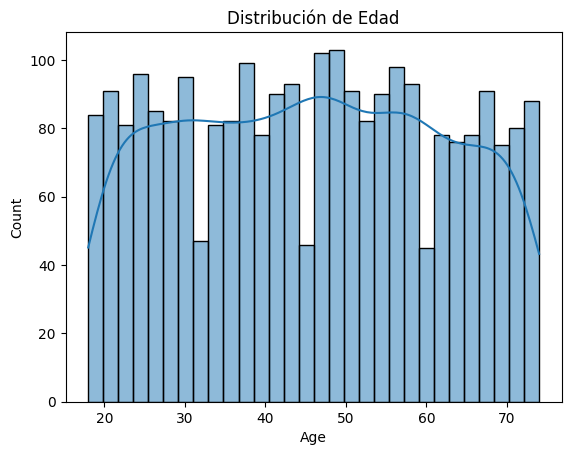

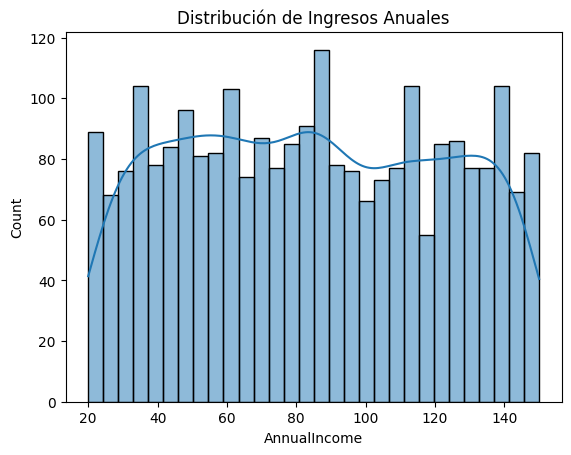

In [1]:
# Análisis Exploratorio Inicial
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Cargar el dataset
df = pd.read_csv('ecommerce_data_1M.csv')
df['LastPurchaseDate'] = pd.to_datetime(df['LastPurchaseDate'])

# Inspección inicial
print(df.info())
print(df.describe())

# Visualización de distribuciones
sns.histplot(df['Age'], kde=True, bins=30)
plt.title('Distribución de Edad')
plt.show()

sns.histplot(df['AnnualIncome'], kde=True, bins=30)
plt.title('Distribución de Ingresos Anuales')
plt.show()

In [2]:
# Tratamiento y Limpieza de Datos
# Manejo de valores nulos
df = df.dropna()

# Normalización de datos
scaler = StandardScaler()
df[['Age', 'AnnualIncome', 'TimeOnSite']] = scaler.fit_transform(df[['Age', 'AnnualIncome', 'TimeOnSite']])

# División en conjuntos de entrenamiento y prueba
features = ['Age', 'AnnualIncome', 'TimeOnSite', 'ItemsInCart']
X = df[features]
y = df['IsSubscribed']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

In [3]:
# 18.9.1 Modelo MLPClassifier Básico
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Entrenamiento del modelo básico
mlp_basic = MLPClassifier(random_state=100)
mlp_basic.fit(X_train, y_train)

# Predicciones y métricas
y_pred_basic = mlp_basic.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred_basic))
print('F1-Score:', f1_score(y_test, y_pred_basic, average='weighted'))
print(classification_report(y_test, y_pred_basic, zero_division=0))

Accuracy: 0.606
F1-Score: 0.5074258010070288
              precision    recall  f1-score   support

           0       0.61      0.94      0.74       304
           1       0.48      0.08      0.14       196

    accuracy                           0.61       500
   macro avg       0.55      0.51      0.44       500
weighted avg       0.56      0.61      0.51       500



In [4]:
# 18.9.2 Modelo MLPClassifier con Hiperparámetros
mlp_tuned = MLPClassifier(random_state=100, hidden_layer_sizes=(100,200,100), max_iter=10000, alpha=1e-5, tol=1e-5)
mlp_tuned.fit(X_train, y_train)

# Predicciones y métricas
y_pred_tuned = mlp_tuned.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred_tuned))
print('F1-Score:', f1_score(y_test, y_pred_tuned, average='weighted'))
print(classification_report(y_test, y_pred_tuned, zero_division=0))

Accuracy: 0.54
F1-Score: 0.5229447415329769
              precision    recall  f1-score   support

           0       0.60      0.71      0.65       304
           1       0.38      0.28      0.32       196

    accuracy                           0.54       500
   macro avg       0.49      0.49      0.49       500
weighted avg       0.52      0.54      0.52       500



In [7]:
# 18.9.3 Red Neuronal Profunda con Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Preparación de datos para Keras
y_train_keras = pd.get_dummies(y_train)
y_test_keras = pd.get_dummies(y_test)

# Definición del modelo
keras_model = Sequential([
    Dense(100, activation='relu', input_dim=X_train.shape[1]),
    Dense(200, activation='relu'),
    Dense(100, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compilación del modelo
keras_model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Entrenamiento
keras_model.fit(X_train, y_train_keras, epochs=50, batch_size=100, verbose=1)

# Evaluación
y_pred_keras = (keras_model.predict(X_test) > 0.5).astype(int)
print('Accuracy:', accuracy_score(y_test_keras, y_pred_keras))
print('F1-Score:', f1_score(y_test_keras, y_pred_keras, average='weighted'))
print(classification_report(y_test_keras, y_pred_keras, zero_division=0))

Epoch 1/50


/home/codespace/.python/current/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


ValueError: Arguments `target` and `output` must have the same shape. Received: target.shape=(100, 2), output.shape=(100, 1)